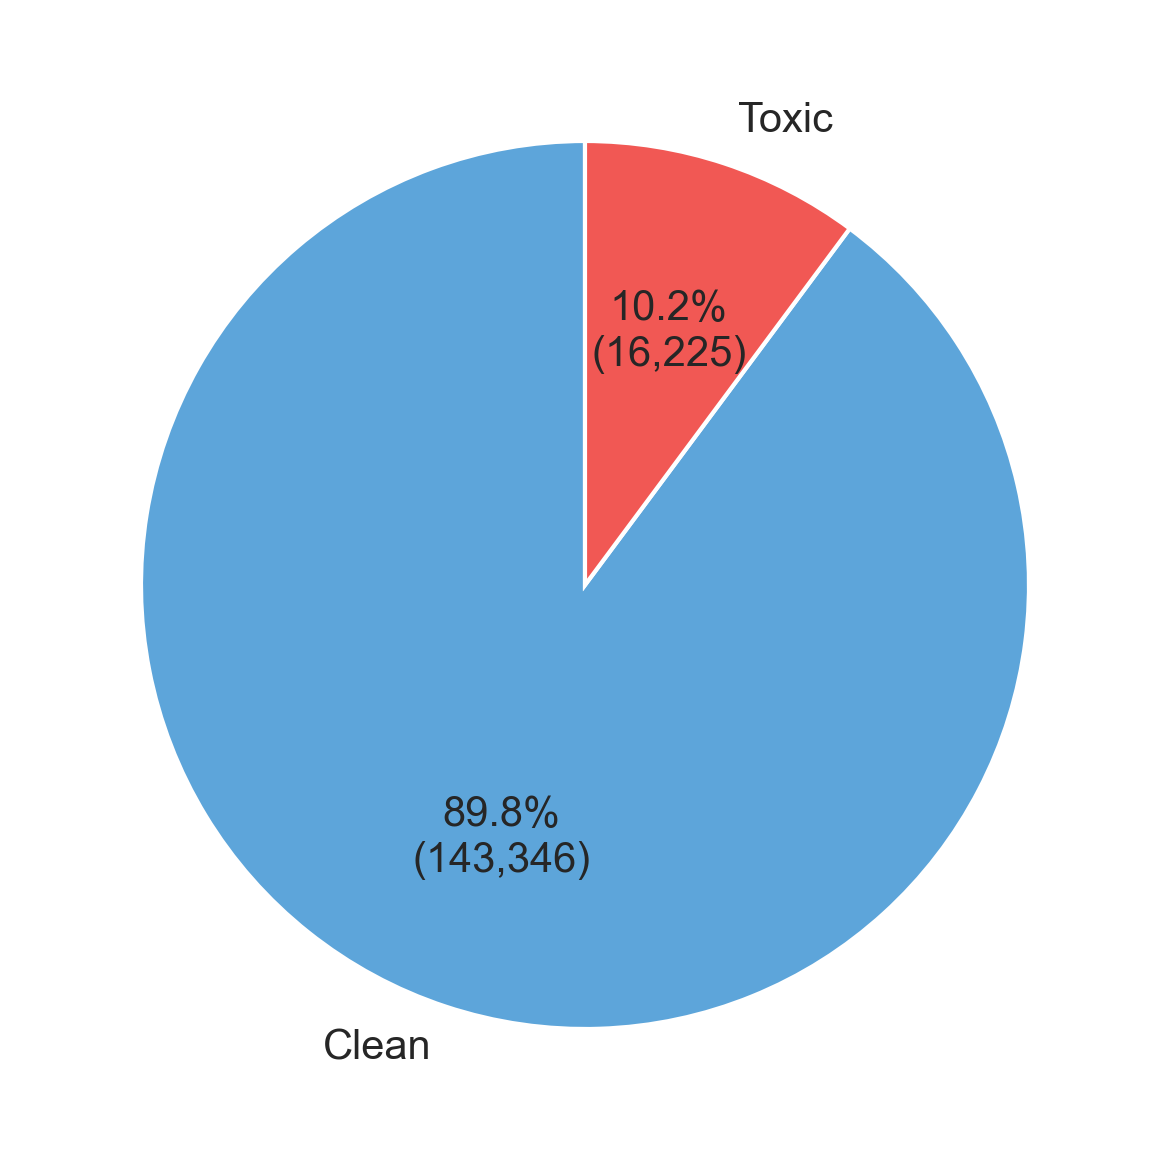

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")
plt.rcParams["figure.dpi"] = 300

labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

train = pd.read_csv("train.csv")

train["is_toxic"] = (train[labels].sum(axis=1) > 0)

counts = train["is_toxic"].value_counts()

clean = counts[False]
toxic = counts[True]

values = [clean, toxic]
names = ["Clean", "Toxic"]

def autopct_format(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100))
        return f"{pct:.1f}%\n({count:,})"
    return inner

colors = ["#5DA5DA", "#F15854"]

fig, ax = plt.subplots(figsize=(4,4))

ax.pie(
    values,
    labels=names,
    autopct=autopct_format(values),
    startangle=90,
    colors=colors,
    textprops={"fontsize":10}
)

# ax.set_title("Figure 1. Class Distribution in the Training Set")

plt.tight_layout()
plt.show()

/var/folders/dq/rz0cpyc93vgd91cjj39nc9nr0000gn/T/ipykernel_33499/1263023942.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


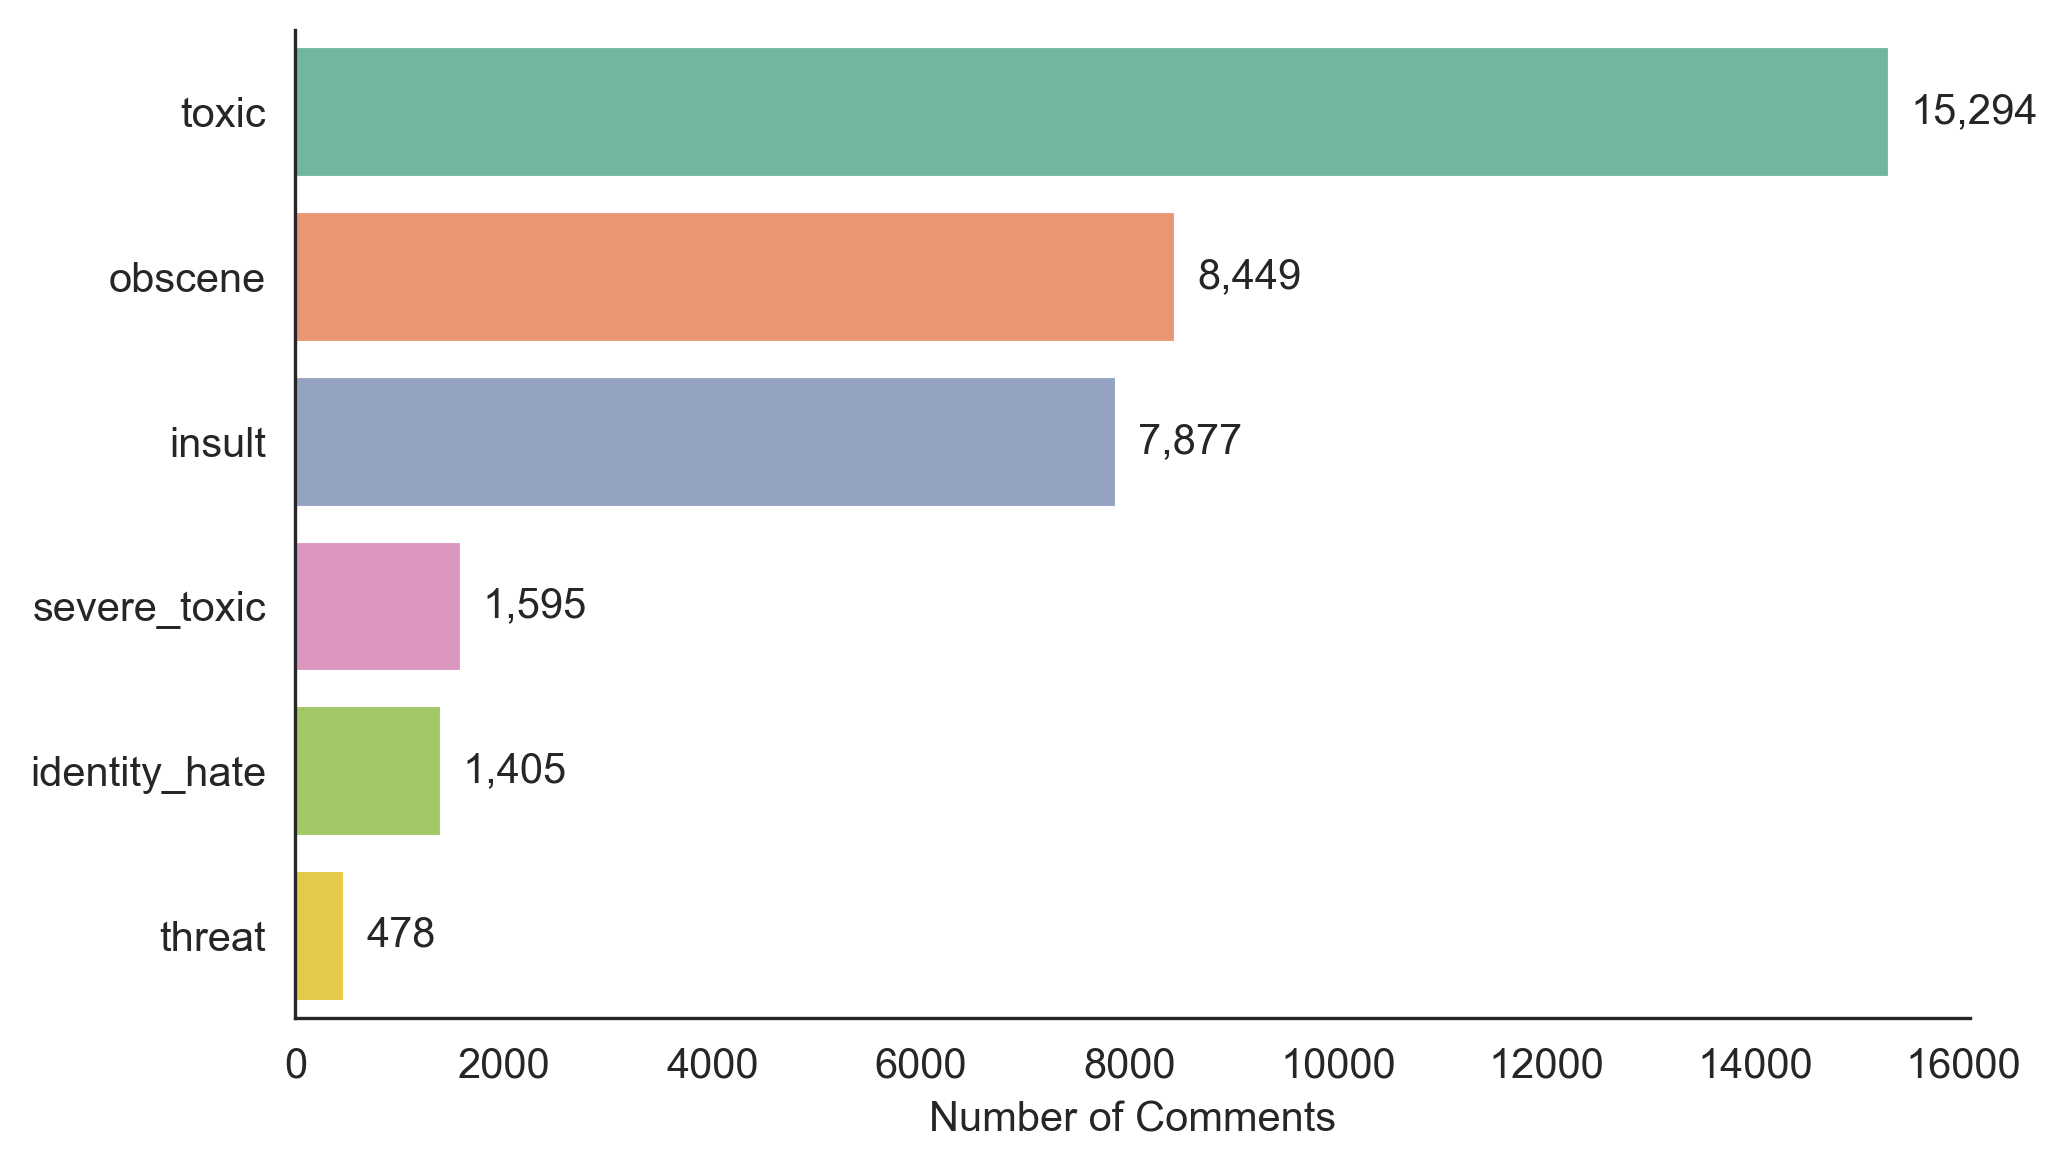

In [6]:
label_counts = train[labels].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7,4))

palette = sns.color_palette("Set2", len(label_counts))

sns.barplot(
    x=label_counts.values,
    y=label_counts.index,
    palette=palette
)

for i, v in enumerate(label_counts.values):
    ax.text(v + 200, i, f"{v:,}", va="center")

ax.set_xlabel("Number of Comments")
ax.set_ylabel("")
# ax.set_title("Figure 2. Distribution of Toxicity Labels")

sns.despine()

plt.tight_layout()
plt.show()